## Dataset Analysis
Perform analysis on distribution of traffic, types of attacks present, and infer the possible variables that may be the factor for attack patterns.

In [ ]:
!pip install -r requirements.txt

In [ ]:
from scipy.io import arff
import pandas as pd

# to avoid base 10 exponents
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

arff_file = arff.loadarff("dataset/KDDTrain+.arff")
train_dataset_df = pd.DataFrame(arff_file[0])

# decode the bytes loaded from scipy (default behavior)
categorical_cols = train_dataset_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    try:
        train_dataset_df[col] = train_dataset_df[col].str.decode('utf-8')

    # exception triggers when the column is already a string
    except AttributeError:
        continue

# normalize the integer columns from float64 -> integer
numeric_real_cols = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "land",
    "logged_in",
    "is_host_login",
    "is_guest_login"
]

for numeric_columns in numeric_real_cols:
    train_dataset_df[numeric_columns] = pd.to_numeric(train_dataset_df[numeric_columns])


In [ ]:
train_dataset_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0.000,tcp,ftp_data,SF,491.000,0.000,0,0.000,0.000,0.000,...,25.000,0.170,0.030,0.170,0.000,0.000,0.000,0.050,0.000,normal
1,0.000,udp,other,SF,146.000,0.000,0,0.000,0.000,0.000,...,1.000,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal
2,0.000,tcp,private,S0,0.000,0.000,0,0.000,0.000,0.000,...,26.000,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,anomaly
3,0.000,tcp,http,SF,232.000,8153.000,0,0.000,0.000,0.000,...,255.000,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal
4,0.000,tcp,http,SF,199.000,420.000,0,0.000,0.000,0.000,...,255.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal


In [ ]:
print(train_dataset_df.columns)
print("colsize: ", len(train_dataset_df.columns))

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='str')
colsize:  42


In [ ]:
train_dataset_df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.000,287.145,2604.515,0.000,0.000,0.000,0.000,42908.000
src_bytes,125973.000,45566.743,5870331.182,0.000,0.000,44.000,276.000,1379963888.000
dst_bytes,125973.000,19779.114,4021269.151,0.000,0.000,0.000,516.000,1309937401.000
land,125973.000,0.000,0.014,0.000,0.000,0.000,0.000,1.000
wrong_fragment,125973.000,0.023,0.254,0.000,0.000,0.000,0.000,3.000
urgent,125973.000,0.000,0.014,0.000,0.000,0.000,0.000,3.000
hot,125973.000,0.204,2.150,0.000,0.000,0.000,0.000,77.000
num_failed_logins,125973.000,0.001,0.045,0.000,0.000,0.000,0.000,5.000
logged_in,125973.000,0.396,0.489,0.000,0.000,0.000,1.000,1.000
num_compromised,125973.000,0.279,23.942,0.000,0.000,0.000,0.000,7479.000


In [ ]:
train_dataset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  float64
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  float64
 5   dst_bytes                    125973 non-null  float64
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  float64
 8   urgent                       125973 non-null  float64
 9   hot                          125973 non-null  float64
 10  num_failed_logins            125973 non-null  float64
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  float64
 13  root_shell

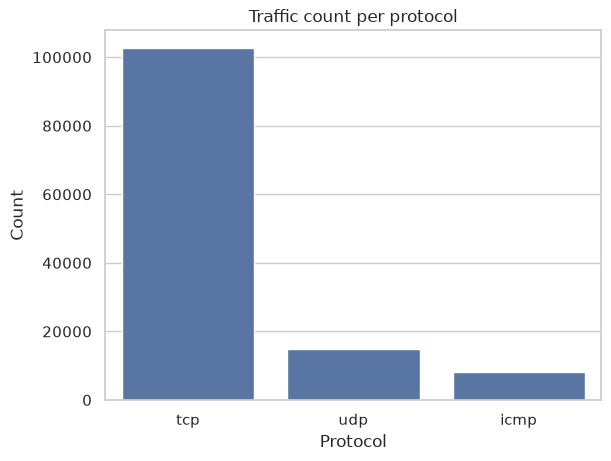

In [ ]:
import seaborn as sn
import matplotlib.pyplot as plt

# show all the protocols available from the dataset
protocols = train_dataset_df["protocol_type"].unique()
plot_data = {
    "Protocol": list(protocols),
    "Count": []
}

for protocol in protocols:
    protocol_count = (train_dataset_df["protocol_type"] == protocol).sum()
    plot_data["Count"].append(protocol_count)

# load a dataframe for the plot data
df = pd.DataFrame(plot_data)

sn.set_theme(style="whitegrid")
sn.barplot(df, x="Protocol", y="Count")

plt.title("Traffic count per protocol")
plt.show()

In [ ]:
# checking for any rows with null values
train_dataset_df[train_dataset_df.isna().any(axis=1)]


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class


no null values for each of the row (probably no corrupted), but we still have to deal with outlier data

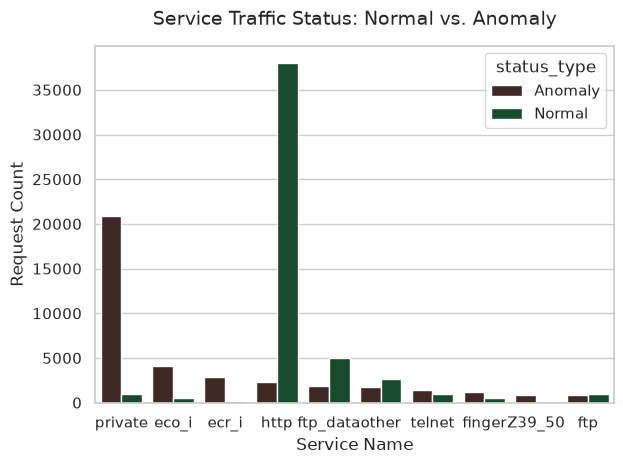

In [ ]:
service_activity_count = pd.crosstab(
    train_dataset_df["service"],
    train_dataset_df["class"],
    margins_name="total_count",
    margins=True,
)

# reset the index to fix the table format 
df_counts = service_activity_count.drop('total_count', axis=0)
df_counts = df_counts.rename(columns={
    'anomaly': 'anomaly_count',
    'normal': 'normal_count'
}).reset_index()


# for getting the top 10 most used service as reference for anomaly checking (can correlate this)
top_10_anomalous_service = df_counts.sort_values(by="anomaly_count", ascending=False).head(10)
top_10_anomalous_order = top_10_anomalous_service["service"].copy().to_list()

top_10_anomalous_service = df_counts[df_counts["service"].isin(top_10_anomalous_service["service"])]

# format to df_long for seaborn to interpret
df_long = pd.melt(
    top_10_anomalous_service, 
    id_vars=["service"], 
    value_vars=["anomaly_count", "normal_count"],
    var_name="status_type", 
    value_name="count"
)

# just for name consistency
df_long['status_type'] = df_long['status_type'].str.replace('_count', '').str.title()

ax = sn.barplot(
    data=df_long,
    x='service',
    y='count',
    hue='status_type',
    order=top_10_anomalous_order,
    palette=["#442420", "#10532c"]
)

ax.set_title('Service Traffic Status: Normal vs. Anomaly', fontsize=14, pad=15)
ax.set_xlabel('Service Name', fontsize=12)
ax.set_ylabel('Request Count', fontsize=12)

plt.tight_layout()
plt.show()

It can be seen here that the `private` service has the highest anomalous packet count, and although `http` packet has one of the highest total packet count, it is not as targeted as `private`, `eco` and `ecr` services, which may indicate something (like, does the network has some sort of weakness over these service?).

context: _`private` services are technically services that are running on a non-common service ports (e.g. web services running on port 9997)_

With this, we can focus more (for now) on analyzing how the `private` service behaves so that we could compare its behavior to other services to look for patterns that may arise, I am aware that I cannot use this to generalize the behavior of other packets, but my objective here is to have a genral idea on how anomalous packets would probably look like based on context of this small dataset.

In [ ]:
service_packets = train_dataset_df[train_dataset_df["service"] == "private"]
service_packets

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
2,0.000,tcp,private,S0,0.000,0.000,0,0.000,0.000,0.000,...,26.000,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,anomaly
5,0.000,tcp,private,REJ,0.000,0.000,0,0.000,0.000,0.000,...,19.000,0.070,0.070,0.000,0.000,0.000,0.000,1.000,1.000,anomaly
6,0.000,tcp,private,S0,0.000,0.000,0,0.000,0.000,0.000,...,9.000,0.040,0.050,0.000,0.000,1.000,1.000,0.000,0.000,anomaly
7,0.000,tcp,private,S0,0.000,0.000,0,0.000,0.000,0.000,...,15.000,0.060,0.070,0.000,0.000,1.000,1.000,0.000,0.000,anomaly
9,0.000,tcp,private,S0,0.000,0.000,0,0.000,0.000,0.000,...,13.000,0.050,0.060,0.000,0.000,1.000,1.000,0.000,0.000,anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125958,0.000,tcp,private,S0,0.000,0.000,0,0.000,0.000,0.000,...,4.000,0.020,0.050,0.000,0.000,1.000,1.000,0.000,0.000,anomaly
125964,0.000,tcp,private,S0,0.000,0.000,0,0.000,0.000,0.000,...,12.000,0.050,0.060,0.000,0.000,1.000,1.000,0.000,0.000,anomaly
125966,0.000,tcp,private,S0,0.000,0.000,0,0.000,0.000,0.000,...,13.000,0.050,0.070,0.000,0.000,1.000,1.000,0.000,0.000,anomaly
125968,0.000,tcp,private,S0,0.000,0.000,0,0.000,0.000,0.000,...,25.000,0.100,0.060,0.000,0.000,1.000,1.000,0.000,0.000,anomaly


## Mutual Information Approach
In this section, I want to experiment and visualize which of the columns affect the packets' class, so I decided to go with mutual information technique to make a straightforward checking, this data can be used for checking which of the column can be weighted more as an input.

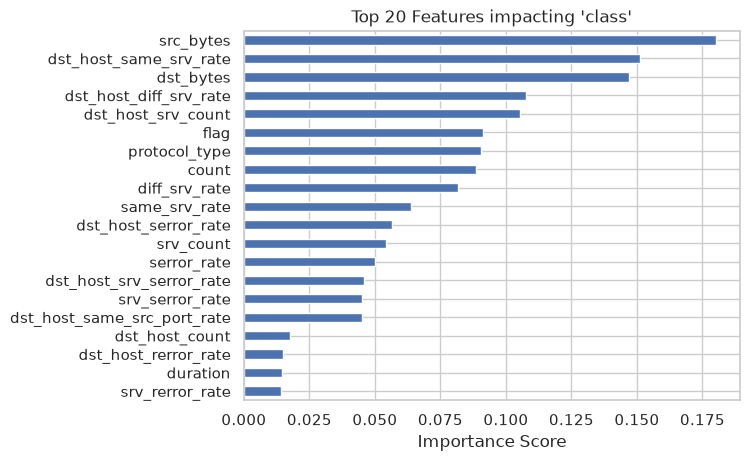

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

X_sample = service_packets.drop(columns=['class'])
y_sample = service_packets['class']

# column conversion for numerical value
for col in X_sample.select_dtypes(include=["object", "str"]).columns:
    X_sample[col] = LabelEncoder().fit_transform(X_sample[col].astype(str))

# label encoder for class
y_encoded_sample = LabelEncoder().fit_transform(y_sample)

mi_scores = mutual_info_classif(X_sample, y_encoded_sample, random_state=67)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X_sample.columns)
mi_scores = mi_scores.sort_values(ascending=False)

# selected columns
sample_mi_cols_20 = mi_scores.head(20).index.to_list()

mi_scores.head(20).plot(kind='barh').invert_yaxis()
plt.title("Top 20 Features impacting 'class'")
plt.xlabel("Importance Score")
plt.show()


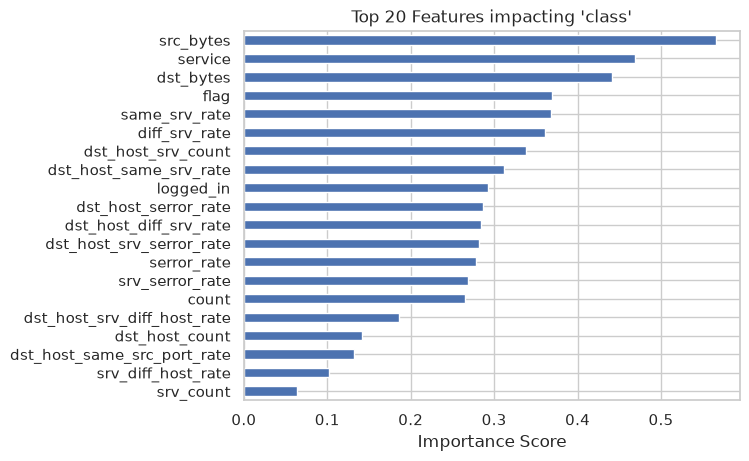

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

X = train_dataset_df.drop(columns=['class'])
y = train_dataset_df['class']

# column conversion for numerical value
for col in X.select_dtypes(include=["object", "str"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# label encoder for class
y_encoded = LabelEncoder().fit_transform(y)

mi_scores = mutual_info_classif(X, y_encoded, random_state=67)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)

# selected mutual info for population
population_mi_cols_20 = mi_scores.head(20).index.to_list()

mi_scores.head(20).plot(kind='barh').invert_yaxis()
plt.title("Top 20 Features impacting 'class'")
plt.xlabel("Importance Score")
plt.show()

## Random Forest Approach
In this approach, I have the same objective as the previous approach, but uses Machine Learning (Random Forest) instead of a statistical (KNN) approach for selecting relevant features for normal vs anomalous packet classification.

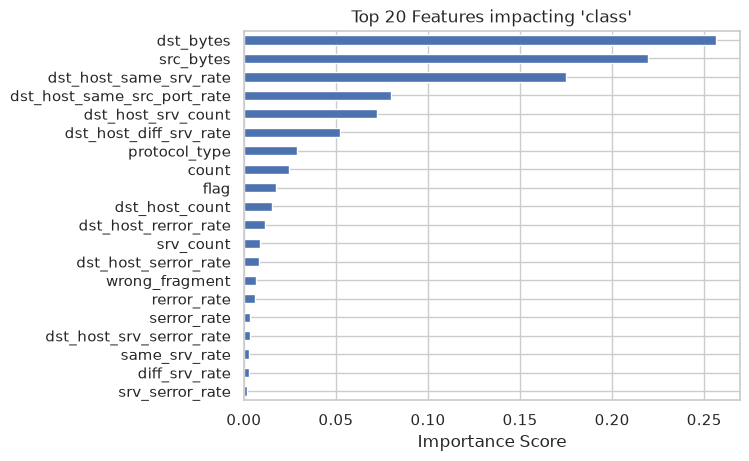

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_sample, y_encoded_sample)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

sample_rf_cols = importances.head(20).index.to_list()

importances.head(20).plot(kind='barh').invert_yaxis()
plt.title("Top 20 Features impacting 'class'")
plt.xlabel("Importance Score")
plt.show()

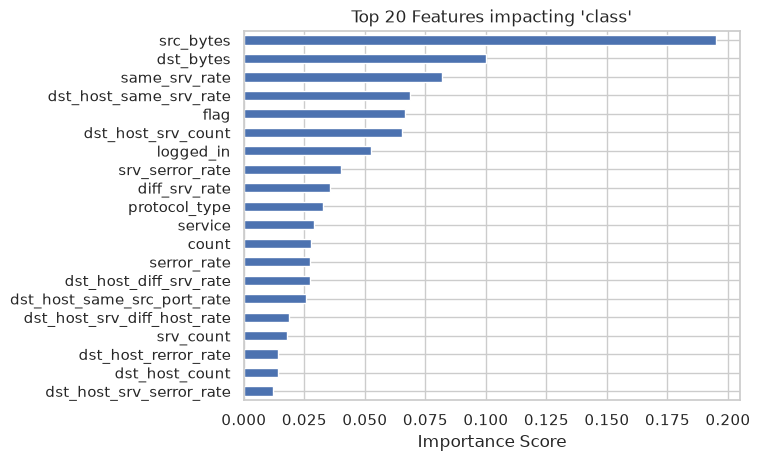

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y_encoded)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

population_rf_cols = importances.head(20).index.to_list()

importances.head(20).plot(kind='barh').invert_yaxis()
plt.title("Top 20 Features impacting 'class'")
plt.xlabel("Importance Score")
plt.show()

After the two different feature selection simple experiment, we can see here that the following columns are present in the data sample and population which means that these features/columns have the major factor for classifying anomalous and normal packets:
- `src_bytes`
- `dst_host_same_srv_rate`
- `dst_bytes`
- `diff_srv_rate`
- `same_srv_rate`
- `dst_host_srv_count`
- `dst_host_diff_srv_rate`
- `dst_host_srv_serror_rate`
- `serror_rate`

The columns: `service` and `flag` are already given for X input as these flags can be used as identifier for the packet (we should always include this).

In [ ]:

sample_cols_considered = set(sample_mi_cols_20 + sample_rf_cols)
population_cols_considered = set(population_mi_cols_20 + population_rf_cols)

print(sample_cols_considered)
print(population_cols_considered)

{'flag', 'srv_rerror_rate', 'dst_bytes', 'duration', 'dst_host_serror_rate', 'dst_host_diff_srv_rate', 'rerror_rate', 'same_srv_rate', 'srv_serror_rate', 'src_bytes', 'dst_host_rerror_rate', 'dst_host_srv_count', 'dst_host_count', 'wrong_fragment', 'diff_srv_rate', 'dst_host_same_srv_rate', 'dst_host_srv_serror_rate', 'serror_rate', 'count', 'dst_host_same_src_port_rate', 'srv_count', 'protocol_type'}
{'flag', 'dst_bytes', 'dst_host_serror_rate', 'dst_host_diff_srv_rate', 'same_srv_rate', 'srv_serror_rate', 'src_bytes', 'dst_host_rerror_rate', 'service', 'dst_host_srv_count', 'dst_host_count', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_same_srv_rate', 'dst_host_srv_serror_rate', 'serror_rate', 'count', 'dst_host_srv_diff_host_rate', 'dst_host_same_src_port_rate', 'logged_in', 'srv_count', 'protocol_type'}
